# `eoflow.samples` — Demonstration Notebook

This notebook walks through the full lifecycle demonstrated by `tests/test_samples_eo_integration.py`:

1. **Load** the Devon water-quality dataset from a GeoPackage
2. **Explore** sample metadata — sites, catchment polygons, pour points
3. **Map** all catchments on an interactive Folium map (Devon context polygon + sample sites)
4. **Connect** to the Copernicus Data Space openEO federation
5. **Query** Sentinel-2 data for a small catchment:
   - Raw bands (B04 Red, B08 NIR)
   - NDVI — vegetation index
   - NDWI — open-water index
   - MNDWI, NDRE, EVI via `query_index()`
   - `days_window` automatic date resolution
   - Cloud-cover filtering
6. **Visualise** each downloaded raster as a Folium `ImageOverlay` on the catchment map
7. **Bulk query** NDVI for all catchments with `query_all_ndvi()`

> **Requirements:** Cached OIDC credentials for the Copernicus Data Space (`openeo-auth` or a prior `conn.authenticate_oidc()` call).  
> The Devon GeoPackage must exist at `../data/devon_water_quality_dataset.gpkg`.

## 0 — Imports & paths

In [ ]:
from __future__ import annotations

import tempfile
import warnings
from pathlib import Path

import branca.colormap as cm
import folium
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import rasterio
import rasterio.warp
from matplotlib.colors import Normalize
from PIL import Image
from pyproj import Transformer
from shapely.geometry import box

from eoflow.samples import (
    OPENEO_BACKEND,
    SENTINEL2_COLLECTION,
    CatchmentDataset,
    CatchmentSample,
)

warnings.filterwarnings("ignore", category=UserWarning)  # suppress openEO cloud-cover warnings

# ---------------------------------------------------------------------------
# Paths — notebook lives in  notebooks/  one level below the repo root
# ---------------------------------------------------------------------------
REPO_ROOT = Path("__file__").resolve().parent.parent  # works in Jupyter
try:
    REPO_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    REPO_ROOT = Path.cwd().parent  # fallback when __file__ is not defined

DATA_DIR      = REPO_ROOT / "data"
GPKG_PATH     = DATA_DIR / "devon_water_quality_dataset.gpkg"
DEVON_SHP     = DATA_DIR / "devon_county" / "devon_county.shp"

assert GPKG_PATH.exists(),  f"GeoPackage not found: {GPKG_PATH}"
assert DEVON_SHP.exists(),  f"Devon shapefile not found: {DEVON_SHP}"

print("Repo root  :", REPO_ROOT)
print("GeoPackage :", GPKG_PATH)
print("Devon SHP  :", DEVON_SHP)

Repo root  : /home/finley/Work/RDS/projects/enforce/repos/eoflow
GeoPackage : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/devon_water_quality_dataset.gpkg
Devon SHP  : /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/devon_county/devon_county.shp


## 1 — Load the Devon water-quality dataset

`CatchmentDataset.from_gpkg()` reads the GeoPackage, reconstructs each catchment polygon from its stored WKT, and wraps every row in a `CatchmentSample` object.

In [2]:
ds = CatchmentDataset.from_gpkg(GPKG_PATH)
print(ds)

2026-02-27 14:42:03,911 - eoflow.samples - INFO - Loaded 10 rows from /home/finley/Work/RDS/projects/enforce/repos/eoflow/data/devon_water_quality_dataset.gpkg
2026-02-27 14:42:03,912 - eoflow.samples - INFO - CatchmentDataset built: 10 samples, 10 with catchments
CatchmentDataset(10 samples, 10 with catchments, source='devon_water_quality_dataset.gpkg')
2026-02-27 14:42:03,912 - eoflow.samples - INFO - CatchmentDataset built: 10 samples, 10 with catchments
CatchmentDataset(10 samples, 10 with catchments, source='devon_water_quality_dataset.gpkg')


In [3]:
# Summary dataframe — one row per sample
summary = ds.summary()
summary[["notation", "site_name", "date", "result", "unit", "has_catchment", "catchment_area_km2"]].style.format(
    {"catchment_area_km2": "{:.3f}", "result": "{:.1f}"}
)

,notation,site_name,date,result,unit,has_catchment,catchment_area_km2
0,SW-70420116,RIVER OTTER AT DOTTON MILL,2020-01-14,57.0,NEPHELOMETRIC TURBIDITY UNITS,True,0.190
1,SW-70540110,RIVER EXE AT TREWS WEIR EXETER,2020-01-22,8.6,NEPHELOMETRIC TURBIDITY UNITS,True,0.158
2,SW-70540224,RIVER EXE AT THORVERTON GAUGING STATION,2020-01-20,5.9,NEPHELOMETRIC TURBIDITY UNITS,True,0.096
3,SW-70620154,RIVER TEIGN AT PRESTON,2020-01-09,15.0,NEPHELOMETRIC TURBIDITY UNITS,True,0.062
4,SW-70631918,KENNICK STREAM AT TOTTIFORD RESERVOIR SURFACE,2020-01-10,1.7,NEPHELOMETRIC TURBIDITY UNITS,True,0.067
5,SW-70720104,RIVER DART AT TOTNES WEIR,2020-01-07,2.3,NEPHELOMETRIC TURBIDITY UNITS,True,0.100
6,SW-70826005,RIVER AVON AT HATCH,2020-01-02,5.0,NEPHELOMETRIC TURBIDITY UNITS,True,0.143
7,SW-70920104,RIVER ERME AT SEQUER'S BRIDGE,2020-01-30,7.0,NEPHELOMETRIC TURBIDITY UNITS,True,0.099
8,SW-72920121,RIVER TORRIDGE AT BEAM BRIDGE,2020-01-24,5.8,NEPHELOMETRIC TURBIDITY UNITS,True,0.358
9,SW-73020127,RIVER TAW AT CHAPELTON FOOTBRIDGE,2020-01-22,6.7,NEPHELOMETRIC TURBIDITY UNITS,True,0.134


## 2 — Inspect an individual sample

We use **River Teign at Preston** (`SW-70620154`) throughout — it has the smallest catchment area (~0.06 km²) which keeps EO downloads fast.

In [4]:
teign = [s for s in ds if s.notation == "SW-70620154"][0]
print(teign)

CatchmentSample
  Site        : RIVER TEIGN AT PRESTON
  Notation    : SW-70620154
  Date        : 2020-01-09
  Measurement : 15.0 NEPHELOMETRIC TURBIDITY UNITS (Turbidity)
  Location    : (50.55941, -3.61672)
  Catchment   : ok — area ≈ 0.062 km²
  Flow acc    : 102.0 cells


In [5]:
print(f"Site         : {teign.site_name}")
print(f"Notation     : {teign.notation}")
print(f"Sample date  : {teign.date}")
print(f"Turbidity    : {teign.result} {teign.unit}")
print(f"Has catchment: {teign.has_catchment}")
print(f"Area         : {teign.catchment_area_km2():.4f} km²")
print(f"BBox (W,S,E,N): {teign.catchment_bbox()}")
print(f"Sample point : lon={teign.longitude:.5f}, lat={teign.latitude:.5f}")
print(f"Snap point   : lon={teign.snap_longitude:.5f}, lat={teign.snap_latitude:.5f}")
print(f"Flow acc.    : {teign.flow_acc_at_pour_point:.0f} cells")

Site         : RIVER TEIGN AT PRESTON
Notation     : SW-70620154
Sample date  : 2020-01-09
Turbidity    : 15.0 NEPHELOMETRIC TURBIDITY UNITS
Has catchment: True
Area         : 0.0619 km²
BBox (W,S,E,N): (-3.61819444442108, 50.55874999999875, -3.6137499999766347, 50.56208333333208)
Sample point : lon=-3.61672, lat=50.55941
Snap point   : lon=-3.61819, lat=50.55986
Flow acc.    : 102 cells


## 3 — Overview map: Devon + all catchment sites

We draw:
* Devon county boundary (grey outline)
* Each delineated catchment polygon (blue fill)
* Original sample point (red circle)
* Snapped pour point (orange triangle) connected by a dashed line
* Popups with key metadata

In [6]:
# ── Load Devon outline ────────────────────────────────────────────────────
devon_gdf = gpd.read_file(DEVON_SHP).to_crs("EPSG:4326")

# ── Build map centred on Devon ────────────────────────────────────────────
DEVON_CENTRE = [50.72, -3.8]

overview_map = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=9,
    tiles="CartoDB positron",
    scrollWheelZoom=False,   # disable scroll zoom as requested
    width="100%",
    height=540,
)

# ── Devon county boundary ─────────────────────────────────────────────────
folium.GeoJson(
    devon_gdf.__geo_interface__,
    name="Devon boundary",
    style_function=lambda _: {
        "fillColor": "#d4e8f0",
        "color": "#2c6e8a",
        "weight": 2,
        "fillOpacity": 0.15,
    },
).add_to(overview_map)

# ── Colour scale for turbidity ────────────────────────────────────────────
results = [s.result for s in ds if s.result is not None]
turb_cmap = cm.LinearColormap(
    ["#2ecc71", "#f39c12", "#e74c3c"],
    vmin=min(results),
    vmax=max(results),
    caption="Turbidity (NTU)",
)
turb_cmap.add_to(overview_map)

# ── Per-sample layers ─────────────────────────────────────────────────────
catchment_fg = folium.FeatureGroup(name="Catchment polygons", show=True)
sites_fg     = folium.FeatureGroup(name="Sample sites",       show=True)
snaps_fg     = folium.FeatureGroup(name="Snapped pour points", show=True)

for s in ds:
    colour = turb_cmap(s.result) if s.result is not None else "#888888"

    popup_html = (
        f"<b>{s.site_name}</b><br>"
        f"Notation : {s.notation}<br>"
        f"Date     : {s.date}<br>"
        f"Turbidity: <b>{s.result} {s.unit}</b><br>"
        f"Area     : {s.catchment_area_km2():.3f} km²<br>"
        f"Flow acc : {s.flow_acc_at_pour_point:.0f} cells"
    )
    popup = folium.Popup(popup_html, max_width=260)

    # Catchment polygon
    if s.has_catchment:
        folium.GeoJson(
            s.catchment_geojson(),
            style_function=lambda _, c=colour: {
                "fillColor": c,
                "color": "#1a1a2e",
                "weight": 1.2,
                "fillOpacity": 0.35,
            },
            tooltip=s.site_name,
            popup=popup,
        ).add_to(catchment_fg)

    # Original sample point
    if s.latitude and s.longitude:
        folium.CircleMarker(
            location=[s.latitude, s.longitude],
            radius=6,
            color="#c0392b",
            fill=True,
            fill_color=colour,
            fill_opacity=0.9,
            tooltip=f"{s.site_name} — {s.result} NTU",
            popup=popup,
        ).add_to(sites_fg)

    # Snapped pour point + offset line
    if s.snap_latitude and s.snap_longitude:
        folium.Marker(
            location=[s.snap_latitude, s.snap_longitude],
            icon=folium.Icon(color="orange", icon="tint", prefix="fa"),
            tooltip=f"Pour point — flow acc: {s.flow_acc_at_pour_point:.0f}",
        ).add_to(snaps_fg)

        if s.latitude and s.longitude:
            folium.PolyLine(
                locations=[[s.latitude, s.longitude], [s.snap_latitude, s.snap_longitude]],
                color="#7f8c8d",
                weight=1.2,
                dash_array="4 4",
            ).add_to(snaps_fg)

catchment_fg.add_to(overview_map)
sites_fg.add_to(overview_map)
snaps_fg.add_to(overview_map)
folium.LayerControl(collapsed=False).add_to(overview_map)

overview_map

## 4 — Connect to openEO (Copernicus Data Space)

`CatchmentSample.connect_openeo()` connects to the Copernicus Data Space federation and authenticates via cached OIDC tokens (no interactive browser flow needed if you have authenticated before).

In [7]:
conn = CatchmentSample.connect_openeo(OPENEO_BACKEND, authenticate=True)
print("Backend    :", OPENEO_BACKEND)
print("Collection :", SENTINEL2_COLLECTION)
account = conn.describe_account()
print("Logged in as:", account.get("name", account.get("user_id", "<unknown>")))

Authenticated using refresh token.
Backend    : openeofed.dataspace.copernicus.eu
Collection : SENTINEL2_L2A
Logged in as: Finley Gibson


In [8]:
# Verify the Sentinel-2 collection is available and inspect its bands
info = conn.describe_collection(SENTINEL2_COLLECTION)
print(f"Collection title : {info.get('title', 'N/A')}")
print(f"Temporal extent  : {info.get('extent', {}).get('temporal', 'N/A')}")

# Extract band names from summaries
summaries = info.get("summaries", {})
bands_meta = summaries.get("eo:bands", [])
band_names = [b["name"] for b in bands_meta if isinstance(b, dict) and "name" in b]
print(f"Bands ({len(band_names)})         : {', '.join(band_names[:15])} …")

Collection title : Sentinel-2 L2A
Temporal extent  : {'interval': [['2015-06-27T10:25:31Z', None]]}
Bands (21)         : B01, B02, B03, B04, B05, B06, B07, B08, B8A, B09, B11, B12, WVP, AOT, SCL …


## 5 — Query raw bands (B04 Red + B08 NIR)

`query_bands()` builds an openEO process graph and downloads a GeoTIFF for the catchment bounding box.  
Sentinel-2 L2A reflectance values are delivered **scaled × 10 000** (integers ~0–10 000).

In [9]:
START_DATE = "2020-01-01"
END_DATE   = "2020-02-01"

# Persistent temp directory — reuse across cells to avoid re-downloading
_tmpdir = tempfile.mkdtemp(prefix="eoflow_demo_")
TMPDIR = Path(_tmpdir)
print("Temp dir:", TMPDIR)

# Build and download the data cube
bands_cube = teign.query_bands(
    conn,
    bands=["B04", "B08"],
    start_date=START_DATE,
    end_date=END_DATE,
)
bands_path = TMPDIR / "bands_B04_B08.tif"
bands_cube.download(str(bands_path), format="GTiff")
print(f"Downloaded → {bands_path.name}  ({bands_path.stat().st_size / 1024:.1f} kB)")

Temp dir: /tmp/eoflow_demo_l0p1gv5n
2026-02-27 14:42:50,868 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B04', 'B08'] | 2020-01-01 → 2020-02-01
Downloaded → bands_B04_B08.tif  (5.0 kB)


CRS    : EPSG:32630
Shape  : (39, 32)  (32 × 39 px)
Bands  : 2
Dtype  : ('int16', 'int16')


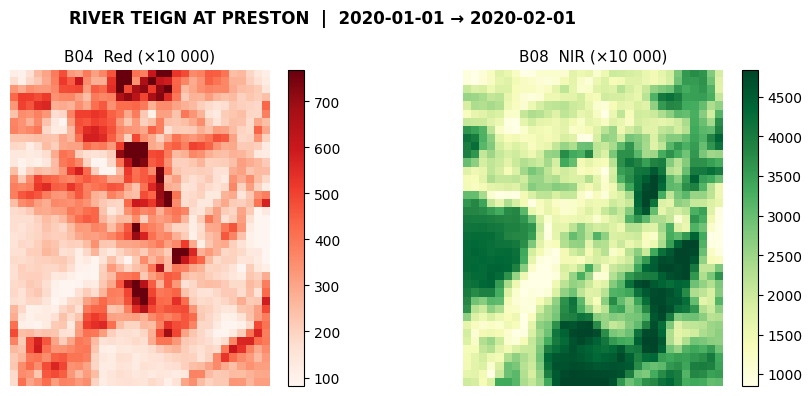

B04  min=44  max=3066  mean=309
B08  min=396  max=5080  mean=2639


In [10]:
with rasterio.open(bands_path) as src:
    b4 = src.read(1).astype(np.float32)
    b8 = src.read(2).astype(np.float32)
    nodata = src.nodata
    crs = src.crs
    print(f"CRS    : {crs}")
    print(f"Shape  : {src.shape}  ({src.width} × {src.height} px)")
    print(f"Bands  : {src.count}")
    print(f"Dtype  : {src.dtypes}")

if nodata is not None:
    b4[b4 == nodata] = np.nan
    b8[b8 == nodata] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, band, label, cmap in zip(axes, [b4, b8], ["B04  Red (×10 000)", "B08  NIR (×10 000)"], ["Reds", "YlGn"]):
    im = ax.imshow(band, cmap=cmap, vmin=np.nanpercentile(band, 2), vmax=np.nanpercentile(band, 98))
    ax.set_title(label, fontsize=11)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"{teign.site_name}  |  {START_DATE} → {END_DATE}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"B04  min={np.nanmin(b4):.0f}  max={np.nanmax(b4):.0f}  mean={np.nanmean(b4):.0f}")
print(f"B08  min={np.nanmin(b8):.0f}  max={np.nanmax(b8):.0f}  mean={np.nanmean(b8):.0f}")

## 6 — NDVI  (Normalised Difference Vegetation Index)

NDVI = (NIR − Red) / (NIR + Red) ∈ (−1, 1).  
Healthy vegetation → high positive values; water/bare soil → near-zero or negative.

2026-02-27 14:43:07,799 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B08', 'B04'] | 2020-01-01 → 2020-02-01
2026-02-27 14:43:07,918 - eoflow.samples - INFO - NDVI process applied (nir=B08, red=B04)
NDVI  min=0.0916  max=0.9579  mean=0.7580  n_pixels=1248


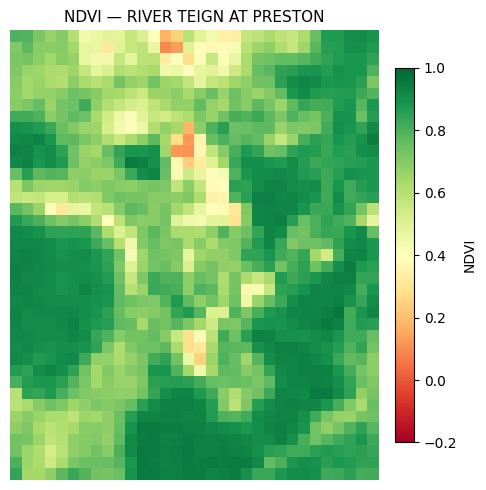

In [11]:
ndvi_cube = teign.query_ndvi(conn, start_date=START_DATE, end_date=END_DATE)
ndvi_path = TMPDIR / "ndvi.tif"
ndvi_cube.download(str(ndvi_path), format="GTiff")

with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1).astype(np.float32)
    ndvi_nodata = src.nodata
    ndvi_transform = src.transform
    ndvi_crs = src.crs
    ndvi_bounds = src.bounds
    ndvi_shape = src.shape

if ndvi_nodata is not None:
    ndvi[ndvi == ndvi_nodata] = np.nan

finite = ndvi[np.isfinite(ndvi)]
print(f"NDVI  min={finite.min():.4f}  max={finite.max():.4f}  mean={finite.mean():.4f}  n_pixels={len(finite)}")

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=1.0)
ax.set_title(f"NDVI — {teign.site_name}", fontsize=11)
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="NDVI")
plt.tight_layout()
plt.show()

## 7 — NDWI  (Normalised Difference Water Index)

NDWI = (Green − NIR) / (Green + NIR).  
Positive values highlight open water; vegetated land returns negative NDWI.

2026-02-27 14:43:24,801 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B03', 'B08'] | 2020-01-01 → 2020-02-01
2026-02-27 14:43:24,905 - eoflow.samples - INFO - NDWI process applied (green=B03, nir=B08)
NDWI  min=-0.8850  max=-0.0573  mean=-0.6793
Mean negative (vegetated land expected)? True


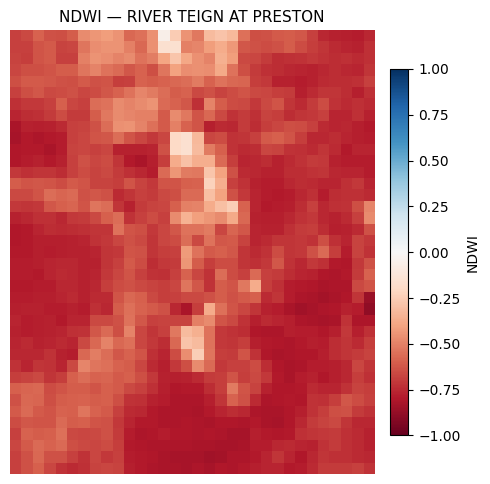

In [12]:
ndwi_cube = teign.query_ndwi(conn, start_date=START_DATE, end_date=END_DATE)
ndwi_path = TMPDIR / "ndwi.tif"
ndwi_cube.download(str(ndwi_path), format="GTiff")

with rasterio.open(ndwi_path) as src:
    ndwi = src.read(1).astype(np.float32)
    nd_nodata = src.nodata
    ndwi_bounds = src.bounds
    ndwi_crs = src.crs

if nd_nodata is not None:
    ndwi[ndwi == nd_nodata] = np.nan

finite_w = ndwi[np.isfinite(ndwi)]
print(f"NDWI  min={finite_w.min():.4f}  max={finite_w.max():.4f}  mean={finite_w.mean():.4f}")
print(f"Mean negative (vegetated land expected)? {finite_w.mean() < 0}")

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(ndwi, cmap="RdBu", vmin=-1.0, vmax=1.0)
ax.set_title(f"NDWI — {teign.site_name}", fontsize=11)
ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="NDWI")
plt.tight_layout()
plt.show()

## 8 — Multiple indices via `query_index()`

The `query_index()` dispatcher supports `NDVI`, `NDWI`, `MNDWI`, `NDRE`, and `EVI` by name (case-insensitive).

2026-02-27 14:43:45,379 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B03', 'B11'] | 2020-01-01 → 2020-02-01
2026-02-27 14:43:45,466 - eoflow.samples - INFO - MNDWI applied (B03, B11)
MNDWI : min=-0.7946  max=0.2424  mean=-0.5113
2026-02-27 14:43:55,924 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B05', 'B04'] | 2020-01-01 → 2020-02-01
2026-02-27 14:43:56,039 - eoflow.samples - INFO - NDRE applied (B05, B04)
NDRE  : min=-0.3156  max=0.8403  mean=0.4410
2026-02-27 14:44:14,797 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B08', 'B04', 'B02'] | 2020-01-01 → 2020-02-01
2026-02-27 14:44:14,908 - eoflow.samples - INFO - EVI applied (nir=B08, red=B04, blue=B02)
EVI   : min=0.0388  max=0.8429  mean=0.4385


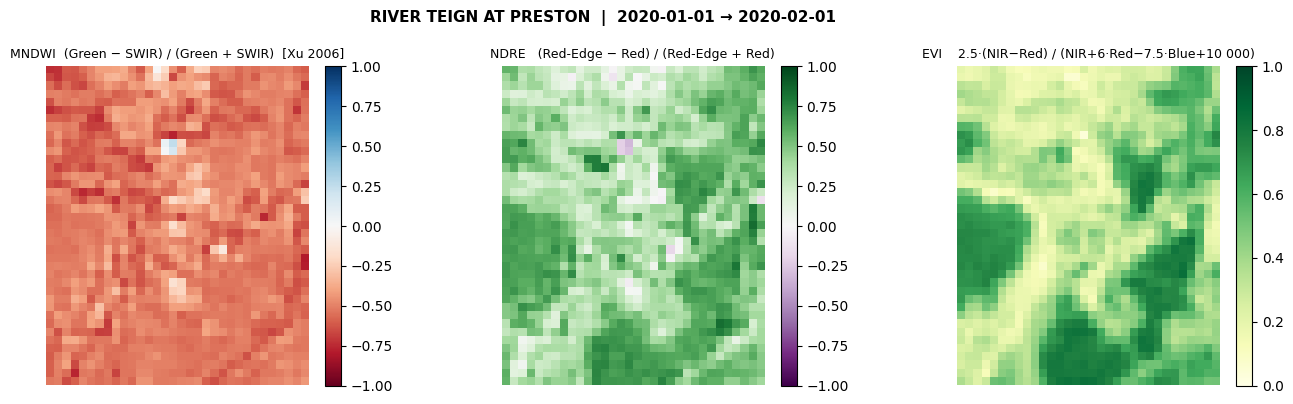

In [13]:
INDICES = ["MNDWI", "NDRE", "EVI"]
INDEX_LABELS = {
    "MNDWI": "MNDWI  (Green − SWIR) / (Green + SWIR)  [Xu 2006]",
    "NDRE":  "NDRE   (Red-Edge − Red) / (Red-Edge + Red)",
    "EVI":   "EVI    2.5·(NIR−Red) / (NIR+6·Red−7.5·Blue+10 000)",
}
INDEX_CMAPS = {"MNDWI": "RdBu", "NDRE": "PRGn", "EVI": "YlGn"}
INDEX_VLIMS = {"MNDWI": (-1, 1), "NDRE": (-1, 1), "EVI": (0, 1)}

index_paths: dict[str, Path] = {}
index_arrays: dict[str, np.ndarray] = {}
index_bounds: dict[str, rasterio.coords.BoundingBox] = {}
index_crs: dict[str, rasterio.crs.CRS] = {}

fig, axes = plt.subplots(1, len(INDICES), figsize=(14, 4))

for ax, idx in zip(axes, INDICES):
    cube = teign.query_index(conn, idx, start_date=START_DATE, end_date=END_DATE)
    path = TMPDIR / f"{idx.lower()}.tif"
    cube.download(str(path), format="GTiff")
    index_paths[idx] = path

    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        nd = src.nodata
        index_bounds[idx] = src.bounds
        index_crs[idx] = src.crs

    if nd is not None:
        arr[arr == nd] = np.nan
    index_arrays[idx] = arr

    finite_i = arr[np.isfinite(arr)]
    print(f"{idx:6s}: min={finite_i.min():.4f}  max={finite_i.max():.4f}  mean={finite_i.mean():.4f}")

    vmin, vmax = INDEX_VLIMS[idx]
    im = ax.imshow(arr, cmap=INDEX_CMAPS[idx], vmin=vmin, vmax=vmax)
    ax.set_title(INDEX_LABELS[idx], fontsize=9)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f"{teign.site_name}  |  {START_DATE} → {END_DATE}", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## 9 — `days_window` automatic date resolution

Instead of specifying explicit dates, pass `days_window=N` and the query window is computed as `sample.date ± N days` automatically.  
When both `days_window` and explicit dates are provided, `days_window` wins.

In [14]:
print(f"Teign sample date: {teign.date}")

from datetime import timedelta
for window in [7, 15, 30]:
    start = teign.date - timedelta(days=window)
    end   = teign.date + timedelta(days=window)
    print(f"  days_window={window:2d}  →  {start}  …  {end}")

Teign sample date: 2020-01-09
  days_window= 7  →  2020-01-02  …  2020-01-16
  days_window=15  →  2019-12-25  …  2020-01-24
  days_window=30  →  2019-12-10  …  2020-02-08


2026-02-27 14:44:41,277 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B08', 'B04'] | 2019-12-25 → 2020-01-24
2026-02-27 14:44:41,366 - eoflow.samples - INFO - NDVI process applied (nir=B08, red=B04)
NDVI (days_window=15): n=1248  min=0.0270  max=0.9334  mean=0.7230


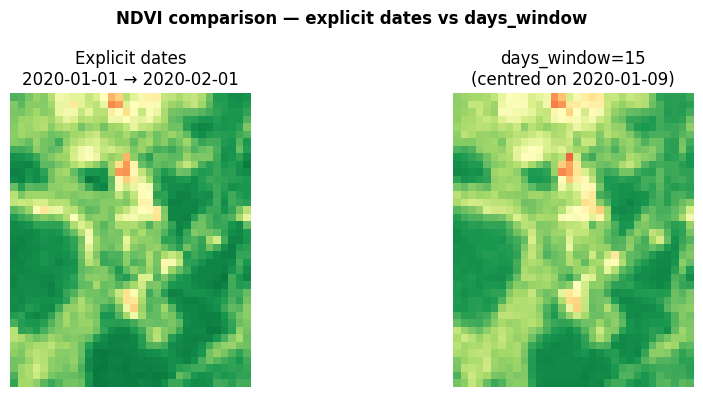

In [15]:
# Query with days_window=15 — no explicit dates required
ndvi_window_cube = teign.query_ndvi(conn, days_window=15)
ndvi_window_path = TMPDIR / "ndvi_window15.tif"
ndvi_window_cube.download(str(ndvi_window_path), format="GTiff")

with rasterio.open(ndvi_window_path) as src:
    ndvi_w = src.read(1).astype(np.float32)
    if src.nodata is not None:
        ndvi_w[ndvi_w == src.nodata] = np.nan

finite_w15 = ndvi_w[np.isfinite(ndvi_w)]
print(f"NDVI (days_window=15): n={len(finite_w15)}  min={finite_w15.min():.4f}  max={finite_w15.max():.4f}  mean={finite_w15.mean():.4f}")

# Compare with explicit-date result side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
kw = dict(cmap="RdYlGn", vmin=-0.2, vmax=1.0)
axes[0].imshow(ndvi,   **kw); axes[0].set_title(f"Explicit dates\n{START_DATE} → {END_DATE}");  axes[0].axis("off")
axes[1].imshow(ndvi_w, **kw); axes[1].set_title(f"days_window=15\n(centred on {teign.date})"); axes[1].axis("off")
fig.suptitle("NDVI comparison — explicit dates vs days_window", fontweight="bold")
plt.tight_layout()
plt.show()

## 10 — Cloud-cover filtering

`max_cloud_cover` is forwarded to `load_collection` to pre-filter scenes before compositing.

2026-02-27 14:44:59,205 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B08', 'B04'] | 2020-01-01 → 2020-02-01
2026-02-27 14:44:59,292 - eoflow.samples - INFO - NDVI process applied (nir=B08, red=B04)
max_cloud_cover=20:  n_pixels=1248  mean_NDVI=0.7580
2026-02-27 14:45:04,453 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B08', 'B04'] | 2020-01-01 → 2020-02-01
2026-02-27 14:45:04,595 - eoflow.samples - INFO - NDVI process applied (nir=B08, red=B04)
max_cloud_cover=85:  n_pixels=1248  mean_NDVI=0.7230


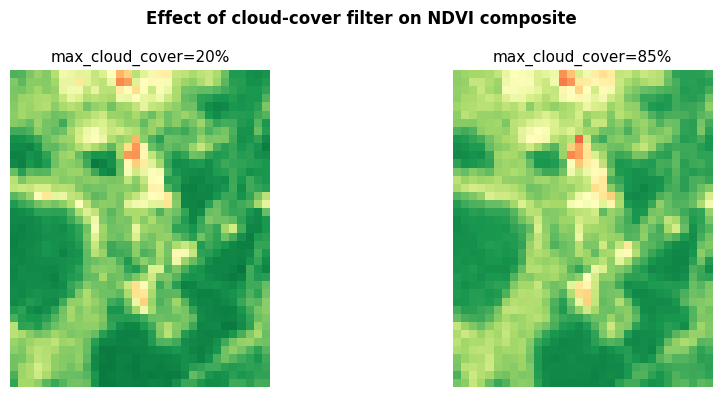

In [16]:
cloud_results: dict[str, np.ndarray] = {}

for cc_limit in [20, 85]:
    cube = teign.query_ndvi(conn, start_date=START_DATE, end_date=END_DATE, max_cloud_cover=cc_limit)
    path = TMPDIR / f"ndvi_cc{cc_limit}.tif"
    cube.download(str(path), format="GTiff")

    with rasterio.open(path) as src:
        arr = src.read(1).astype(np.float32)
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
    cloud_results[cc_limit] = arr
    finite_cc = arr[np.isfinite(arr)]
    print(f"max_cloud_cover={cc_limit:2d}:  n_pixels={len(finite_cc)}  mean_NDVI={finite_cc.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (cc, arr) in zip(axes, cloud_results.items()):
    ax.imshow(arr, cmap="RdYlGn", vmin=-0.2, vmax=1.0)
    ax.set_title(f"max_cloud_cover={cc}%", fontsize=11)
    ax.axis("off")
fig.suptitle("Effect of cloud-cover filter on NDVI composite", fontweight="bold")
plt.tight_layout()
plt.show()

## 11 — Second site: River Otter at Dotton Mill

We verify that the spatial extent logic works across different catchments — the Otter and Teign rasters should have distinct geographic footprints.

CatchmentSample(id='https://environment.data.gov.uk/water-quality/sampling-point/SW-70420116/sample/3399126/observation/6396', site='RIVER OTTER AT DOTTON MILL', date=datetime.date(2020, 1, 14), result=57.0, has_catchment=True)
2026-02-27 14:45:20,698 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER OTTER AT DOTTON MILL' | bands=['B08', 'B04'] | 2020-01-01 → 2020-02-01
2026-02-27 14:45:20,784 - eoflow.samples - INFO - NDVI process applied (nir=B08, red=B04)
Otter NDVI: n=4104  min=-0.0035  max=0.9025  mean=0.7642

Longitude offset between sites: 0.314°  (expect >0.1°)


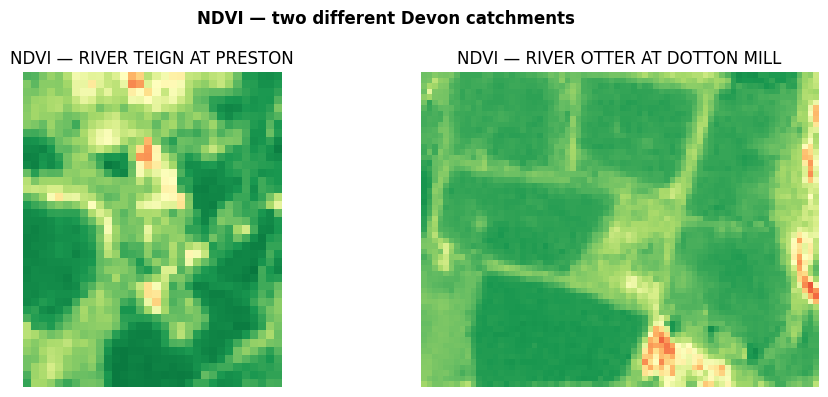

In [17]:
otter = [s for s in ds if s.notation == "SW-70420116"][0]
print(repr(otter))

otter_ndvi_cube = otter.query_ndvi(conn, start_date=START_DATE, end_date=END_DATE)
otter_ndvi_path = TMPDIR / "otter_ndvi.tif"
otter_ndvi_cube.download(str(otter_ndvi_path), format="GTiff")

with rasterio.open(otter_ndvi_path) as src:
    otter_ndvi = src.read(1).astype(np.float32)
    otter_bounds = src.bounds
    otter_crs = src.crs
    if src.nodata is not None:
        otter_ndvi[otter_ndvi == src.nodata] = np.nan

finite_o = otter_ndvi[np.isfinite(otter_ndvi)]
print(f"Otter NDVI: n={len(finite_o)}  min={finite_o.min():.4f}  max={finite_o.max():.4f}  mean={finite_o.mean():.4f}")

# Confirm their bboxes differ
lon_diff = abs(otter.catchment_bbox()[0] - teign.catchment_bbox()[0])
print(f"\nLongitude offset between sites: {lon_diff:.3f}°  (expect >0.1°)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(ndvi,       cmap="RdYlGn", vmin=-0.2, vmax=1.0); axes[0].set_title(f"NDVI — {teign.site_name}");  axes[0].axis("off")
axes[1].imshow(otter_ndvi, cmap="RdYlGn", vmin=-0.2, vmax=1.0); axes[1].set_title(f"NDVI — {otter.site_name}"); axes[1].axis("off")
fig.suptitle("NDVI — two different Devon catchments", fontweight="bold")
plt.tight_layout()
plt.show()

## 12 — Bulk NDVI query with `query_all_ndvi()`

`CatchmentDataset.query_all_ndvi()` iterates over every delineated sample, submits an NDVI query for each, and optionally downloads all rasters into an output directory.

In [18]:
# Filter to a single small catchment to keep this cell fast
teign_ds = ds.filter(site_name_contains="TEIGN AT PRESTON")
print(f"Filtered dataset: {len(teign_ds)} sample(s)")

bulk_outdir = TMPDIR / "bulk_ndvi"
bulk_outdir.mkdir(exist_ok=True)

cubes = teign_ds.query_all_ndvi(
    conn,
    days_window=20,
    output_dir=bulk_outdir,
)

print(f"\nDataCubes returned: {list(cubes.keys())}")
for f in sorted(bulk_outdir.glob("*.tif")):
    print(f"  {f.name}  ({f.stat().st_size / 1024:.1f} kB)")

Filtered dataset: 1 sample(s)
2026-02-27 14:45:44,267 - eoflow.samples - INFO - Running NDVI queries for 1 samples …
2026-02-27 14:45:44,268 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B08', 'B04'] | 2019-12-20 → 2020-01-29
2026-02-27 14:45:44,268 - eoflow.samples - INFO - Loading SENTINEL2_L2A for site 'RIVER TEIGN AT PRESTON' | bands=['B08', 'B04'] | 2019-12-20 → 2020-01-29
2026-02-27 14:45:44,355 - eoflow.samples - INFO - NDVI process applied (nir=B08, red=B04)
2026-02-27 14:45:44,356 - eoflow.samples - INFO - Downloading NDVI → /tmp/eoflow_demo_l0p1gv5n/bulk_ndvi/SW-70620154_ndvi.tif

DataCubes returned: ['SW-70620154']
  SW-70620154_ndvi.tif  (5.0 kB)


## 13 — Raster helper: reproject to WGS 84 for Folium overlays

Folium's `ImageOverlay` expects a PNG with geographic bounds in WGS 84 (EPSG:4326).  
We reproject the UTM raster, apply a matplotlib colormap, and encode the result as a base-64 PNG.

In [19]:
import io, base64

def raster_to_folium_overlay(
    tif_path: Path,
    cmap_name: str = "RdYlGn",
    vmin: float | None = None,
    vmax: float | None = None,
    alpha: float = 0.65,
) -> tuple[str, list[list[float]]]:
    """Reproject a single-band GeoTIFF to WGS84 and return
    (base64-encoded PNG string, [[south, west], [north, east]]) for
    use with folium.raster_layers.ImageOverlay.
    """
    dst_crs = rasterio.crs.CRS.from_epsg(4326)

    with rasterio.open(tif_path) as src:
        # Compute the output transform and shape in WGS84
        transform_wgs84, width_wgs84, height_wgs84 = rasterio.warp.calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update(
            crs=dst_crs,
            transform=transform_wgs84,
            width=width_wgs84,
            height=height_wgs84,
            nodata=np.nan,
            dtype="float32",
        )

        # Write reprojected raster to an in-memory buffer
        mem_path = TMPDIR / (tif_path.stem + "_wgs84.tif")
        with rasterio.open(mem_path, "w", **kwargs) as dst:
            rasterio.warp.reproject(
                source=rasterio.band(src, 1),
                destination=rasterio.band(dst, 1),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform_wgs84,
                dst_crs=dst_crs,
                resampling=rasterio.warp.Resampling.bilinear,
            )

    with rasterio.open(mem_path) as src_wgs84:
        data = src_wgs84.read(1).astype(np.float32)
        bounds_wgs84 = src_wgs84.bounds  # (left, bottom, right, top) in lon/lat

    # Mask nodata
    data[~np.isfinite(data)] = np.nan

    # Normalise to [0, 1] for colourmap
    v0 = vmin if vmin is not None else np.nanpercentile(data, 2)
    v1 = vmax if vmax is not None else np.nanpercentile(data, 98)
    norm = Normalize(vmin=v0, vmax=v1, clip=True)
    cmap = matplotlib.colormaps[cmap_name]

    # Apply colormap → RGBA uint8
    rgba = cmap(norm(data), bytes=True)          # (H, W, 4)
    rgba[~np.isfinite(data), 3] = 0              # transparent where NaN
    rgba[np.isfinite(data),  3] = int(alpha * 255)

    # Encode as base-64 PNG
    img = Image.fromarray(rgba, mode="RGBA")
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    png_b64 = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

    # Folium bounds: [[south, west], [north, east]]
    folium_bounds = [
        [bounds_wgs84.bottom, bounds_wgs84.left],
        [bounds_wgs84.top,    bounds_wgs84.right],
    ]
    return png_b64, folium_bounds

print("Helper defined — ready to build overlay maps.")

Helper defined — ready to build overlay maps.


## 14 — Teign catchment map with NDVI overlay

In [20]:
def make_catchment_map(sample: CatchmentSample, zoom: int = 14) -> folium.Map:
    """Return a Folium map centred on `sample` with its catchment polygon drawn."""
    lat_c = (sample.catchment_bbox()[1] + sample.catchment_bbox()[3]) / 2
    lon_c = (sample.catchment_bbox()[0] + sample.catchment_bbox()[2]) / 2

    m = folium.Map(
        location=[lat_c, lon_c],
        zoom_start=zoom,
        tiles="CartoDB positron",
        scrollWheelZoom=False,
        width="100%",
        height=480,
    )

    # Catchment polygon
    folium.GeoJson(
        sample.catchment_geojson(),
        name="Catchment",
        style_function=lambda _: {
            "fillColor": "#3498db",
            "color": "#1a5276",
            "weight": 2,
            "fillOpacity": 0.0,   # transparent fill — raster overlay goes underneath
        },
        tooltip=sample.site_name,
    ).add_to(m)

    # Sample point
    folium.CircleMarker(
        location=[sample.latitude, sample.longitude],
        radius=7,
        color="#c0392b",
        fill=True,
        fill_color="#e74c3c",
        fill_opacity=0.9,
        tooltip=f"Sample site: {sample.site_name}",
    ).add_to(m)

    # Snapped pour point
    folium.Marker(
        location=[sample.snap_latitude, sample.snap_longitude],
        icon=folium.Icon(color="orange", icon="tint", prefix="fa"),
        tooltip=f"Pour point (flow acc={sample.flow_acc_at_pour_point:.0f})",
    ).add_to(m)

    # Offset line
    folium.PolyLine(
        [[sample.latitude, sample.longitude], [sample.snap_latitude, sample.snap_longitude]],
        color="#7f8c8d", weight=1.5, dash_array="5 5",
    ).add_to(m)

    return m


# Build base map
teign_map = make_catchment_map(teign, zoom=15)

# Add NDVI overlay
ndvi_png, ndvi_wgs84_bounds = raster_to_folium_overlay(
    ndvi_path, cmap_name="RdYlGn", vmin=-0.2, vmax=1.0, alpha=0.70
)
folium.raster_layers.ImageOverlay(
    image=ndvi_png,
    bounds=ndvi_wgs84_bounds,
    name="NDVI",
    opacity=1.0,
    interactive=False,
    cross_origin=False,
).add_to(teign_map)

# Colourbar
ndvi_cbar = cm.LinearColormap(
    ["#d73027", "#fee08b", "#1a9850"],
    vmin=-0.2, vmax=1.0,
    caption="NDVI",
)
ndvi_cbar.add_to(teign_map)
folium.LayerControl(collapsed=False).add_to(teign_map)

teign_map

## 15 — Side-by-side NDVI & NDWI overlay map

In [21]:
teign_multi_map = make_catchment_map(teign, zoom=15)

# NDVI layer
ndvi_png, ndvi_wgs84_bounds = raster_to_folium_overlay(
    ndvi_path, cmap_name="RdYlGn", vmin=-0.2, vmax=1.0, alpha=0.65
)
folium.raster_layers.ImageOverlay(
    image=ndvi_png, bounds=ndvi_wgs84_bounds,
    name="NDVI (RdYlGn)", opacity=1.0, interactive=False,
).add_to(teign_multi_map)

# NDWI layer (hidden by default — toggle via layer control)
ndwi_png, ndwi_wgs84_bounds = raster_to_folium_overlay(
    ndwi_path, cmap_name="RdBu", vmin=-1.0, vmax=1.0, alpha=0.65
)
folium.raster_layers.ImageOverlay(
    image=ndwi_png, bounds=ndwi_wgs84_bounds,
    name="NDWI (RdBu)", opacity=1.0, interactive=False, show=False,
).add_to(teign_multi_map)

# EVI layer (hidden by default)
evi_png, evi_wgs84_bounds = raster_to_folium_overlay(
    index_paths["EVI"], cmap_name="YlGn", vmin=0.0, vmax=0.9, alpha=0.65
)
folium.raster_layers.ImageOverlay(
    image=evi_png, bounds=evi_wgs84_bounds,
    name="EVI (YlGn)", opacity=1.0, interactive=False, show=False,
).add_to(teign_multi_map)

cm.LinearColormap(
    ["#d73027", "#fee08b", "#1a9850"], vmin=-0.2, vmax=1.0, caption="NDVI",
).add_to(teign_multi_map)

folium.LayerControl(collapsed=False).add_to(teign_multi_map)

teign_multi_map

## 16 — Multi-site NDVI comparison map

NDVI overlays for both the **Teign** and **Otter** catchments on a shared Devon-scale map, demonstrating that independent spatial extents are computed correctly for each site.


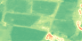

In [22]:
multi_site_map = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=10,
    tiles="CartoDB positron",
    scrollWheelZoom=False,
    width="100%",
    height=500,
)

# Devon outline
folium.GeoJson(
    devon_gdf.__geo_interface__,
    name="Devon boundary",
    style_function=lambda _: {
        "fillColor": "#d4e8f0", "color": "#2c6e8a",
        "weight": 2, "fillOpacity": 0.12,
    },
).add_to(multi_site_map)

SITE_COLOURS = {
    teign.notation: "#8e44ad",
    otter.notation: "#e67e22",
}

for sample, ndvi_arr_path, label in [
    (teign, ndvi_path,       "Teign NDVI"),
    (otter, otter_ndvi_path, "Otter NDVI"),
]:
    border_col = SITE_COLOURS[sample.notation]

    # Catchment polygon
    folium.GeoJson(
        sample.catchment_geojson(),
        name=f"{sample.site_name} — catchment",
        style_function=lambda _, c=border_col: {
            "fillColor": c, "color": c,
            "weight": 2.5, "fillOpacity": 0.0,
        },
        tooltip=sample.site_name,
        popup=folium.Popup(
            f"<b>{sample.site_name}</b><br>"
            f"Turbidity: {sample.result} {sample.unit}<br>"
            f"Area: {sample.catchment_area_km2():.3f} km²",
            max_width=220,
        ),
    ).add_to(multi_site_map)

    # NDVI raster overlay
    png, bounds = raster_to_folium_overlay(
        ndvi_arr_path, cmap_name="RdYlGn", vmin=-0.2, vmax=1.0, alpha=0.70
    )
    folium.raster_layers.ImageOverlay(
        image=png, bounds=bounds,
        name=label, opacity=1.0, interactive=False,
    ).add_to(multi_site_map)

    # Site marker
    folium.CircleMarker(
        location=[sample.latitude, sample.longitude],
        radius=7, color=border_col, fill=True,
        fill_color=border_col, fill_opacity=0.9,
        tooltip=f"{sample.site_name} — {sample.result} NTU",
    ).add_to(multi_site_map)

cm.LinearColormap(
    ["#d73027", "#fee08b", "#1a9850"], vmin=-0.2, vmax=1.0, caption="NDVI",
).add_to(multi_site_map)
folium.LayerControl(collapsed=False).add_to(multi_site_map)

multi_site_map

## 17 — Error handling demonstration

Attempting to run an EO query on a sample with no delineated catchment raises a descriptive `ValueError` before any network call is made.

In [23]:
import pandas as pd

no_catchment = CatchmentSample(
    row=pd.Series({
        "id": "fake-001",
        "samplingPoint.prefLabel": "Hypothetical Site",
        "samplingPoint.notation": "FAKE-001",
        "latitude": 50.72,
        "longitude": -3.80,
        "result": 12.5,
        "unit": "NTU",
        "determinand.prefLabel": "Turbidity",
        "Date": "2020-01-15",
        "delineation_status": "failed",
        "delineation_error": "no stream found within search radius",
    }),
    catchment=None,
)

print(f"has_catchment = {no_catchment.has_catchment}")

try:
    no_catchment.query_bands(conn, bands=["B04"], start_date=START_DATE, end_date=END_DATE)
except ValueError as exc:
    print(f"\nGot expected ValueError:\n  {exc}")

has_catchment = False

Got expected ValueError:
  Sample 'fake-001' has no delineated catchment polygon — cannot define a spatial extent for the EO query.


In [24]:
# Unknown index name is also caught locally — no network call
try:
    teign.query_index(conn, "MAGIC_INDEX", start_date=START_DATE, end_date=END_DATE)
except ValueError as exc:
    print(f"Got expected ValueError:\n  {exc}")

Got expected ValueError:
  Unknown index 'MAGIC_INDEX'. Supported indices: EVI, MNDWI, NDRE, NDVI, NDWI. For arbitrary bands use query_bands() instead.


## 18 — Full Devon NDVI overview map (all catchments)

A final map combining Devon county boundary, all delineated catchment polygons coloured by turbidity, all sample/pour-point markers, and NDVI raster overlays for the two sites we downloaded.


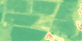

In [25]:
final_map = folium.Map(
    location=DEVON_CENTRE,
    zoom_start=9,
    tiles="CartoDB positron",
    scrollWheelZoom=False,
    width="100%",
    height=580,
)

# ── Devon outline ─────────────────────────────────────────────────────────
folium.GeoJson(
    devon_gdf.__geo_interface__,
    name="Devon boundary",
    style_function=lambda _: {
        "fillColor": "#d4e8f0", "color": "#2c6e8a",
        "weight": 2, "fillOpacity": 0.12,
    },
).add_to(final_map)

# ── Turbidity colour scale ────────────────────────────────────────────────
results_all = [s.result for s in ds if s.result is not None]
turb_cmap2 = cm.LinearColormap(
    ["#2ecc71", "#f39c12", "#e74c3c"],
    vmin=min(results_all), vmax=max(results_all),
    caption="Turbidity (NTU)",
)
turb_cmap2.add_to(final_map)

# ── All catchments ────────────────────────────────────────────────────────
catch_fg = folium.FeatureGroup(name="Catchment polygons", show=True)
for s in ds:
    if not s.has_catchment:
        continue
    col = turb_cmap2(s.result) if s.result is not None else "#95a5a6"
    folium.GeoJson(
        s.catchment_geojson(),
        style_function=lambda _, c=col: {
            "fillColor": c, "color": "#1a1a2e",
            "weight": 1.2, "fillOpacity": 0.30,
        },
        tooltip=s.site_name,
        popup=folium.Popup(
            f"<b>{s.site_name}</b><br>"
            f"Turbidity: {s.result} {s.unit}<br>"
            f"Date: {s.date}<br>"
            f"Area: {s.catchment_area_km2():.3f} km²<br>"
            f"Flow acc: {s.flow_acc_at_pour_point:.0f} cells",
            max_width=230,
        ),
    ).add_to(catch_fg)
catch_fg.add_to(final_map)

# ── Sample + pour-point markers ───────────────────────────────────────────
markers_fg = folium.FeatureGroup(name="Sample sites & pour points", show=True)
for s in ds:
    col = turb_cmap2(s.result) if s.result is not None else "#95a5a6"
    if s.latitude and s.longitude:
        folium.CircleMarker(
            location=[s.latitude, s.longitude],
            radius=6, color="#2c3e50", fill=True,
            fill_color=col, fill_opacity=0.9,
            tooltip=f"{s.site_name}  —  {s.result} NTU",
        ).add_to(markers_fg)
    if s.snap_latitude and s.snap_longitude:
        folium.Marker(
            location=[s.snap_latitude, s.snap_longitude],
            icon=folium.Icon(color="orange", icon="tint", prefix="fa"),
            tooltip=f"Pour point — {s.site_name}",
        ).add_to(markers_fg)
        if s.latitude and s.longitude:
            folium.PolyLine(
                [[s.latitude, s.longitude], [s.snap_latitude, s.snap_longitude]],
                color="#7f8c8d", weight=1.2, dash_array="4 4",
            ).add_to(markers_fg)
markers_fg.add_to(final_map)

# ── NDVI raster overlays for the two downloaded sites ────────────────────
ndvi_rasters_fg = folium.FeatureGroup(name="NDVI rasters (Teign & Otter)", show=True)
for sample, path in [(teign, ndvi_path), (otter, otter_ndvi_path)]:
    png, bounds = raster_to_folium_overlay(
        path, cmap_name="RdYlGn", vmin=-0.2, vmax=1.0, alpha=0.72
    )
    folium.raster_layers.ImageOverlay(
        image=png, bounds=bounds,
        name=f"NDVI — {sample.site_name}",
        opacity=1.0, interactive=False,
    ).add_to(ndvi_rasters_fg)
ndvi_rasters_fg.add_to(final_map)

cm.LinearColormap(
    ["#d73027", "#fee08b", "#1a9850"], vmin=-0.2, vmax=1.0, caption="NDVI",
).add_to(final_map)
folium.LayerControl(collapsed=False).add_to(final_map)

final_map

## Summary

| Step | API used | What it demonstrated |
|------|----------|----------------------|
| Load dataset | `CatchmentDataset.from_gpkg()` | Reads GeoPackage, reconstructs polygons, wraps in `CatchmentSample` |
| Inspect metadata | `CatchmentSample` properties | `site_name`, `date`, `result`, `catchment_bbox()`, `catchment_area_km2()`, `flow_acc_at_pour_point` |
| Overview map | `folium.Map` + `GeoJson` + `CircleMarker` | Devon boundary, all catchments coloured by turbidity |
| Connect | `CatchmentSample.connect_openeo()` | OIDC auth to Copernicus Data Space |
| Raw bands | `query_bands(["B04", "B08"])` | Scaled ×10 000 S2 reflectance, 2-band GeoTIFF, UTM CRS |
| NDVI | `query_ndvi()` | Built-in openEO `ndvi` process; values ∈ (−1, 1) |
| NDWI | `query_ndwi()` | Custom band-math; negative for vegetated land |
| MNDWI / NDRE / EVI | `query_index("MNDWI")` etc. | Generic dispatcher; case-insensitive names |
| Date window | `days_window=15` | Auto-computes ±N-day window around sample date |
| Cloud filter | `max_cloud_cover=20 / 85` | Fewer vs more scenes composited |
| Second site | Otter `query_ndvi()` | Distinct spatial extent, same pipeline |
| Bulk query | `CatchmentDataset.query_all_ndvi()` | Iterates all catchments, saves `<notation>_ndvi.tif` files |
| Error handling | `ValueError` on missing catchment / unknown index | Raised locally, no network call |
| Map overlays | `folium.raster_layers.ImageOverlay` | Reprojected WGS84 PNG coloured by NDVI/NDWI/EVI |